Author: Daniel Abadjiev  
Date: Apr 27, 2026  
Description: Play around with some models to get a data rate.  

In [1]:
import tensorflow as tf
from datetime import datetime
from tfLoaderUtils import *
import numpy as np
import qkeras
import matplotlib.pyplot as plt
import dataRateUtils 
modelType = 2

2026-05-01 15:17:45.944569: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-01 15:17:45.946739: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 15:17:45.989749: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-01 15:17:45.990940: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-01 15:17:46.723238: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

<class 'MuC_Smartpix_ML.Model_Classes.SmartPixModel'>
weird import error
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
True
True
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
False


2026-05-01 15:17:48.361858: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...
2026-05-01 15:17:48.366506: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1960] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_4w0i_hyperparameter_results_20260222_004048/model_trial_000.h5"
filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_quantized_8w0i_hyperparameter_results_20260228_020952/model_trial_0.h5"
filepath="./model_trial_0.h5"
if modelType==2:
    filepath="../../Muon_Collider_Smart_Pixels/eric/model2.5_qi_4w0i_pareto_roc_selected/model_trial_25.h5"
    filepath="../eric/Model2_5_tahn/model2.5_quantizedinputs_8w0i_pareto_roc_selected/model_trial_065.h5"
# filepath = "../../smart-pixels-ml/DanielModels/model2_20260325.keras"
#Now trying an Ryan model
if modelType==1:
    filepath="/home/dabadjiev/smartpixels_ml_dsabadjiev/Muon_Collider_Smart_Pixels/ryan/old_quantization_res/model1_quantized_4w0i_pareto/model_trial_034.h5"
co = {}       
qkeras.utils._add_supported_quantized_objects(co)
quantizedModel = tf.keras.models.load_model(filepath,custom_objects=co,compile=True)
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_dir_catapult = "./hlsCatapultModel2_"+timestamp
output_dir_vitis = "./hlsVitisModel2_"+timestamp
quantizedModel.summary()

Model: "model2_5_qi_8w0i_hp_tuning"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 x_profile (InputLayer)      [(None, 21)]                 0         []                            
                                                                                                  
 y_profile (InputLayer)      [(None, 13)]                 0         []                            
                                                                                                  
 q_input_x_profile (QActiva  (None, 21)                   0         ['x_profile[0][0]']           
 tion)                                                                                            
                                                                                                  
 q_input_y_profile (QActiva  (None, 13)                   0         ['y_p

In [3]:
dataRateUtils.modelSpecsToDataRate(2.5, quantizedModel)


Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 3s 58ms/step


Data rate at fpr 0.06794440362700724 and threshold [0.765625]
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
Data rate at fpr 0.10901883951490743 and threshold [0.4609375]
Data rate at fpr 0.1388911565242894 and threshold [0.1796875]
✓ Model2.5 evaluation completed!
  Test Loss: 0.1931
  Test Accuracy: 0.9363
  ROC AUC: 0.9690

  Background Rejection Metrics (Bkg Rej = 1 - FPR):
    @ 90% signal efficiency: Bkg Rej = 0.9321 (FPR = 0.067944), Back Data Accep = 0.0386
    @ 98% signal efficiency: Bkg Rej = 0.8910 (FPR = 0.109019), Back Data Accep = 0.0647
    @ 99% signal efficiency: Bkg Rej = 0.8611 (FPR = 0.138891), Back Data Accep = 0.0845


In [4]:
raise ValueError("end notebook here")

ValueError: end notebook here

In [ ]:

# # if loadTestVectors:
# #     [yTest, xTestList] = pickle.load(open(f"./testVectors{modelType}.pkl",'rb'))
# #     xTest = pickle.load(open(f"./tfTestVectors{modelType}.pkl",'rb'))
    
# #     # [yTest, xTestList] = pickle.load(open(f"./testVectors.pkl",'rb'))
# #     # xTest = pickle.load(open(f"./tfTestVectors.pkl",'rb'))
# # else:
# # xTest, yTest, xTestList, xTrain, yTrain = flattenTfData(modelType)
# xTestWithNpix, yTestWithNpix, xTestListWithNpix, xTrainWithNpix, yTrainWithNpix, = flattenTfData(modelType,includenPix=True)
# #     if saveTestVectors:
# #         pickle.dump([yTest, xTestList],open(f"./testVectors{modelType}.pkl","wb"))
# #         pickle.dump(xTest,open(f"./tfTestVectors{modelType}.pkl","wb"))
# # # xTest, yTest, = flattenTfData(2,doTrain=False)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41


In [ ]:
#Now in dataRateUtils.modelSpecsToDataRate
tfRecordFolder = "/local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData"
model = Model2_5(tfRecordFolder = tfRecordFolder)   
configName = "justThisOne"
model.models[configName] = quantizedModel

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
Evaluating Model2.5 [justThisOne]...
41/41 [==============================] - 2s 56ms/step


Data rate at fpr 0.06794440362700724
Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41
accepted background samples:  103620
total background samples:  330741
backgorund acceptance:  0.31329650693442906
Total background pixel count:  2000084.0
[ 4. 22.  8. ... 15.  5.  9.]
(array([     3,      6,     19, ..., 330728, 330732, 330737]), array([0, 0, 0, ..., 0, 0, 0]))


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

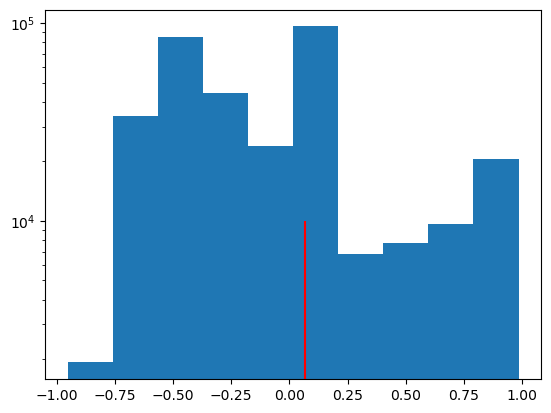

In [ ]:
model.evaluate(config_name=configName)

In [ ]:
nPixes, yTest = getNpixYtest(model)

In [ ]:
# model.evaluate(config_name = configName)

predictions = model.models[configName].predict(model.validation_generator, verbose=1)
print(predictions)
predictions = predictions.ravel()


/home/dabadjiev/miniconda3/envs/newHLSEnviro/lib/python3.8/site-packages/keras/src/engine/functional.py:639: UserWarning: Input dict contained keys ['nPix'] which did not match any model input. They will be ignored by the model.
  inputs = self._flatten_to_reference_inputs(inputs)


41/41 [==============================] - 3s 60ms/step
[[ 0.8828125]
 [ 0.5703125]
 [-0.4453125]
 ...
 [ 0.953125 ]
 [-0.3046875]
 [-0.0234375]]


accepted background samples:  47339
total background samples:  330741
backgorund acceptance:  0.14313012296630898
Total background pixel count:  2000084.0
Accepted background pixel count:  175659.0
Data rate of background acceptance:  0.08782581


(175659.0, 2000084.0, 0.08782581)

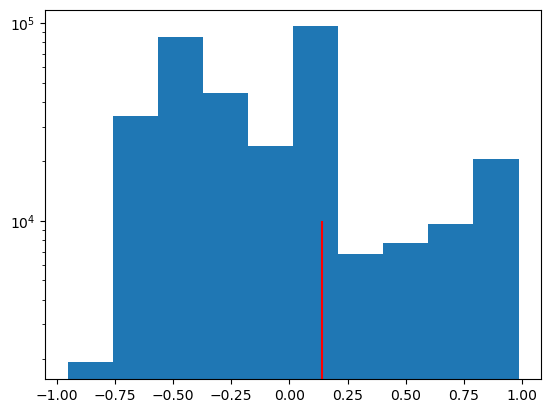

In [ ]:
# nPixes = xTestWithNpix["nPix"]
#functions moved to script
dataRateUtils.pixPredictToDataRate(yTest,nPixes,predictions)


In [ ]:
#functions moved to script


In [ ]:
xTest, yTest, xTestList, xTrain, yTrain = flattenTfData(1)

Loading training data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_train/
Loading validation data from: /local/d1/smartpixML/2026Datasets/Data_Files/Data_Set_2026V2_Apr/TF_Records/filtering_records16384_data_shuffled_single_bigData/tfrecords_validation/
Using batch_size=16384 to match TFRecord format


Training generator length: 164
Validation generator length: 41


[0.14285715 0.14285715 0.0952381  ... 0.04761905 0.14285715 0.0952381 ]


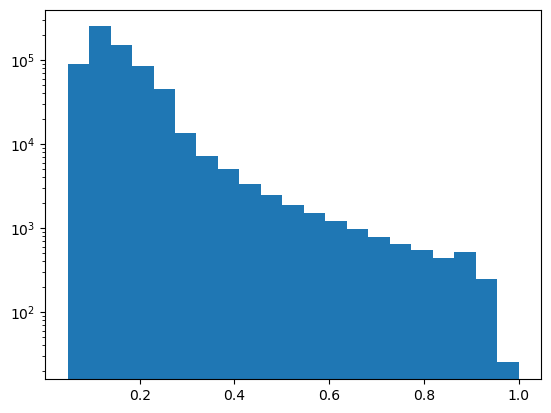

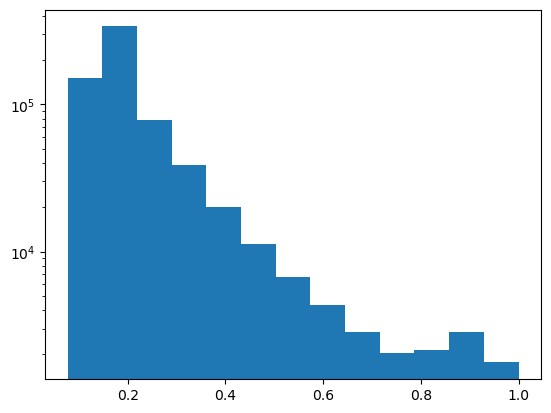

In [ ]:
print(xTest["x_size"].numpy())
plt.hist(xTest["x_size"].numpy(),bins=21)
plt.yscale('log')
plt.show()
plt.hist(xTest["y_size"].numpy(),bins =13)
plt.yscale('log')
plt.show()

In [ ]:
plt.hist(xTest["y_size"])